# Problem 1: Dealing with Data (15)

#### a)

A data engineer at Car Dealership was not careful in writing the excel file and put multiple sheets in the file. In your Jupyter Notebook, show us how you can import the excel file by specifying the correct sheet and header condition in such a way that you have a clean dataframe to work with.

*if you are unable to solve (a), you can manually delete the first row in the excel file and attempt the questions below, but that will result in a penalty during marking.* (3)

In [92]:
import pandas as pd

# 1. Load the specific sheet and define the header row
df = pd.read_excel('cars.xlsx', sheet_name='cars', header=3)

# 2. Display the first few rows to verify it is clean
print(df.head())

# 3. Optional: Check data types and missing values
print(df.info())


  manufacturer_name model_name transmission  color  odometer_value  \
0        Alfa Romeo         75   mechanical  green          125000   
1        Alfa Romeo        164   mechanical  green          123214   
2        Alfa Romeo         33   mechanical    red          218000   
3        Alfa Romeo        164   mechanical   blue           12354   
4        Alfa Romeo        146   mechanical    red          452000   

   year_produced engine_fuel  engine_has_gas engine_type  engine_capacity  \
0           1987    gasoline           False    gasoline              2.0   
1           1989      diesel           False      diesel              2.5   
2           1993    gasoline           False    gasoline              1.4   
3           1993      diesel           False      diesel              2.5   
4           1995      diesel           False      diesel              1.9   

   ... feature_1  feature_2 feature_3 feature_4  feature_5  feature_6  \
0  ...     False      False     False     F

#### b)

Find out what are the datatypes of each column in the dataset. Comment on how many columns are Object datatype columns. Create two dataframes, in which one only has the Object datatype columns and one does not have the Object datatype columns. (3)

In [74]:
# 2. Find out the datatypes of each column
print("Data types of each column:")
print(df.dtypes)
print("-" * 30)

# 3. Comment on how many columns are Object datatype columns
object_cols = df.select_dtypes(include=['object']).columns
print(f"Number of Object datatype columns: {len(object_cols)}")
print(f"Object columns: {list(object_cols)}")
print("-" * 30)

# 4. Create two dataframes: One with only Object types, one without
df_objects = df.select_dtypes(include=['object'])
df_numeric = df.select_dtypes(exclude=['object'])

# Displaying first few rows of each to verify
print("DataFrame with only Object columns:")
print(df_objects.head())
print("\nDataFrame without Object columns:")
print(df_numeric.head())

Data types of each column:
manufacturer_name     object
model_name            object
transmission          object
color                 object
odometer_value         int64
year_produced          int64
engine_fuel           object
engine_has_gas          bool
engine_type           object
engine_capacity      float64
body_type             object
has_warranty            bool
state                 object
drivetrain            object
price_usd            float64
is_exchangeable         bool
location_region       object
number_of_photos     float64
up_counter           float64
feature_0               bool
feature_1               bool
feature_2               bool
feature_3               bool
feature_4               bool
feature_5               bool
feature_6               bool
feature_7               bool
feature_8               bool
feature_9               bool
duration_listed        int64
dtype: object
------------------------------
Number of Object datatype columns: 10
Object columns: ['ma

#### c)

The same data engineer also made a mistake during data transfer and there are null (NaN) values in some of the columns. By getting a new numeric dataframe, use the `.fillna()` function to replace those null values in the dataframe with the last 2 digits of your matriculation ID. Also states which columns has null (NAN) values. [For example, if your Matriculation ID Number is U0000099X, use #99]  (3)

In [75]:
fill_value = 44 
df_numeric_filled = df_numeric.fillna(fill_value)

# 5. State which columns have null (NAN) values.
null_columns = df_numeric.columns[df_numeric.isnull().any()]
print(f"\nColumns with null values in numeric dataframe: {list(null_columns)}")
print(f"Total null values replaced: {df_numeric.isnull().sum().sum()}")


Columns with null values in numeric dataframe: ['number_of_photos', 'up_counter']
Total null values replaced: 3


#### d)

Use the `.iloc` function to find the row corresponding to the last 2 digits of your matriculation ID in the dataframe and print out the `model_name`, `year_produced` and `duration_listed` of that car. (3)

In [76]:
# 6. Use .iloc to find specific car details
if len(df_numeric_filled) > fill_value:
    car_row = df_numeric_filled.iloc[fill_value]
    car_row_obj = df.iloc[fill_value]
    print(f"\nDetails for row {fill_value}:")
    print(f"Model Name: {car_row_obj.get('model_name', 'N/A')}")
    print(f"Year Produced: {car_row.get('year_produced', 'N/A')}")
    print(f"Duration Listed: {car_row.get('duration_listed', 'N/A')}")
else:
    print(f"\nRow {fill_value} is out of bounds.")


Details for row 44:
Model Name: Xsara Picasso
Year Produced: 2002
Duration Listed: 0


#### e)

Create a new dataframe where you only have the `manufacturer_name` and `year_produced` columns. Then sort the dataframe according to `year_produced` in descending order using the `.sort_values()` function. Print the new dataframe and comment on the oldest car manufacturer name in the dataframe. [you can find information about the `sort_values()` function online] (3)

In [77]:
# 6. Create new dataframe with manufacturer_name and year_produced
df_subset = df[['manufacturer_name', 'year_produced']].copy()

# Sort by year_produced descending
df_sorted = df_subset.sort_values(by='year_produced', ascending=False)
print("--- Sorted DataFrame (Descending Year) ---")
print(df_sorted.head())

# Comment on oldest car manufacturer
oldest_car = df_sorted.iloc[-1]
print(f"\nOldest car manufacturer: {oldest_car['manufacturer_name']} in {oldest_car['year_produced']}")

--- Sorted DataFrame (Descending Year) ---
    manufacturer_name  year_produced
364             Geely           2019
241              Fiat           2019
420              LADA           2019
421              LADA           2019
422              LADA           2019

Oldest car manufacturer: Dacia in 1978


# Problem 2: Classification (50)

#### a)

Import the `CA2_red_white_wine.csv` csv file and print the overall statistical description of the data and plot standard statistical distributions for each variable, including for the categorical variable. (6)

--- Overall Statistical Description (Numeric Variables) ---
       fixed acidity    chlorides  total sulfur dioxide           pH  \
count    1401.000000  1401.000000           1400.000000  1398.000000   
mean        7.189008     0.063329            101.100714     3.262217   
std         1.123404     0.037086             64.904162     0.160781   
min         5.000000     0.020000              6.000000     2.850000   
25%         6.500000     0.044000             39.000000     3.150000   
50%         7.000000     0.055000             98.000000     3.270000   
75%         7.600000     0.076000            153.000000     3.370000   
max        12.600000     0.415000            313.000000     4.010000   

           alcohol  
count  1400.000000  
mean     10.400464  
std       1.110081  
min       8.500000  
25%       9.500000  
50%      10.200000  
75%      11.200000  
max      14.000000  

--- Overall Statistical Description (Categorical Variable) ---
        type
count   1401
unique     2

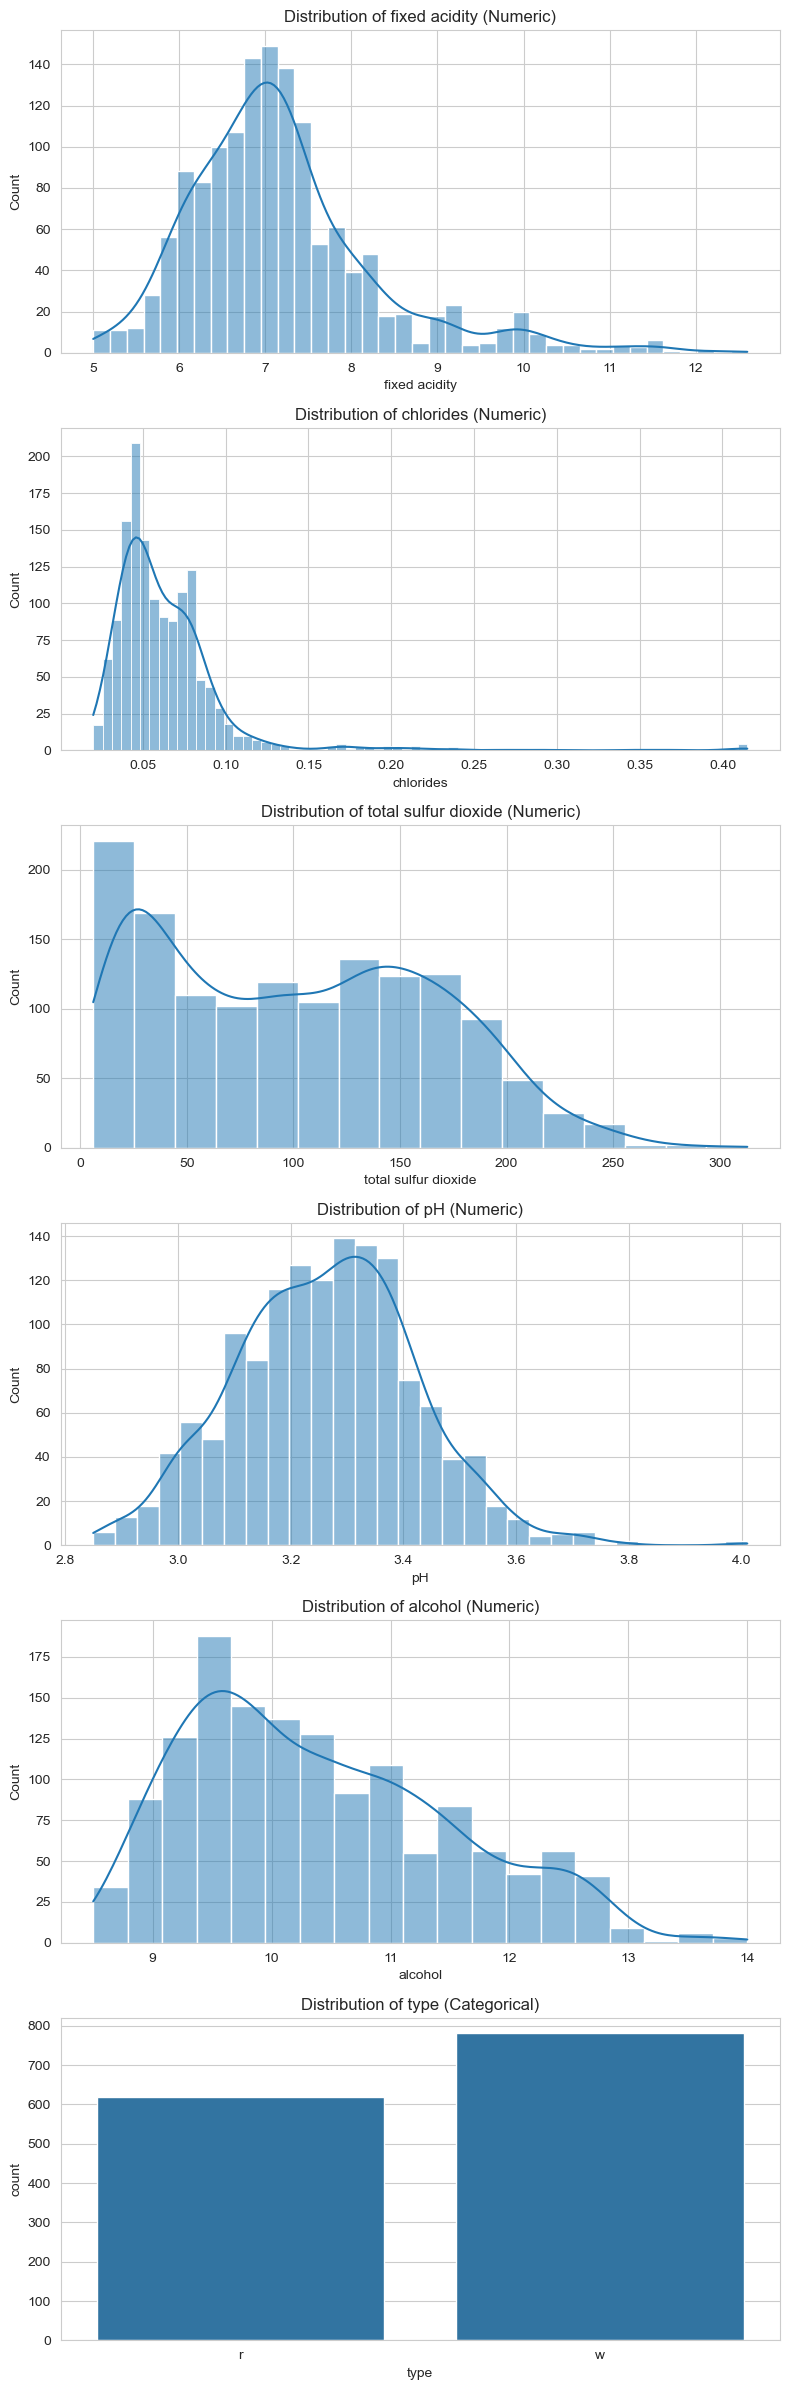

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visualization style
sns.set_style("whitegrid")

# 1. Import the dataset
file_path = 'CA2_red_white_wine.csv'
df = pd.read_csv(file_path) #

# 2. Print the overall statistical description of the data
print("--- Overall Statistical Description (Numeric Variables) ---")
print(df.describe()) #

print("\n--- Overall Statistical Description (Categorical Variable) ---")
# Include 'all' data types for description of categorical data
print(df.describe(include=['O'])) # 


# 3. Plot standard statistical distributions for each variable

# Configure plot display for multiple plots
num_cols = len(df.columns)
# Adjust the figure size based on the number of columns to prevent overlap
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(8, 4 * num_cols)) 
# If only one column, axes won't be a list, so wrap it
if num_cols == 1:
    axes = [axes]


for i, col in enumerate(df.columns):
    ax = axes[i]
    if pd.api.types.is_numeric_dtype(df[col]):
        # Plot distribution for numeric variables (histogram and KDE)
        sns.histplot(df[col], kde=True, ax=ax) #
        ax.set_title(f'Distribution of {col} (Numeric)')
    else:
        # Plot distribution for categorical variable (count plot/bar chart)
        sns.countplot(x=col, data=df, ax=ax) #
        ax.set_title(f'Distribution of {col} (Categorical)')

plt.tight_layout()
plt.show()


#### b)

Remove from this dataset, all rows containing NaN values. Only use this cleaned dataset from now on. (3)

In [79]:
# Display original shape
print(f"Original shape: {df.shape}")

# 2. Remove rows containing NaN values
df_cleaned = df.dropna()

# Display new shape and confirm no NaN values remain
print(f"Shape after removing NaNs: {df_cleaned.shape}")
print(f"Missing values check:\n{df_cleaned.isnull().sum().sum()}")

df = df_cleaned

Original shape: (1401, 6)
Shape after removing NaNs: (1396, 6)
Missing values check:
0


#### c)

Calculate the ratio of White/Red in type of wines (don't hard code, extract the values and compute based on dataset). Print this ratio. (3)

In [80]:
# 2. Count the occurrences of each wine type
# value_counts() provides counts of unique values in the column
type_counts = df['type'].value_counts()

# 3. Extract the counts for 'White' and 'Red'
# The .get() method is used to safely retrieve the count, returning 0 if the value isn't found
white_count = type_counts.get('w', 0)
red_count = type_counts.get('r', 0)

# 4. Calculate the ratio (White/Red)
if red_count > 0:
    ratio = white_count / red_count
    print(f"The count of White wines is: {white_count}")
    print(f"The count of Red wines is: {red_count}")
    print(f"The ratio of White/Red wines is: {ratio}")
else:
    print("Cannot calculate the ratio as there are no Red wines in the dataset.")

The count of White wines is: 781
The count of Red wines is: 615
The ratio of White/Red wines is: 1.269918699186992


#### d)

Visualize the relationship amongst type of wines and all other numeric variables (total of 5 variables) using mutual boxplots and swarmplots. (3)

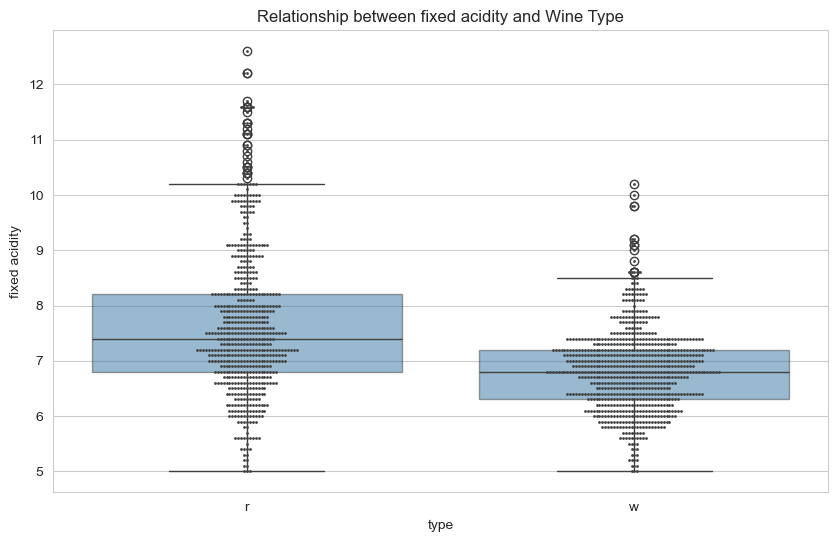

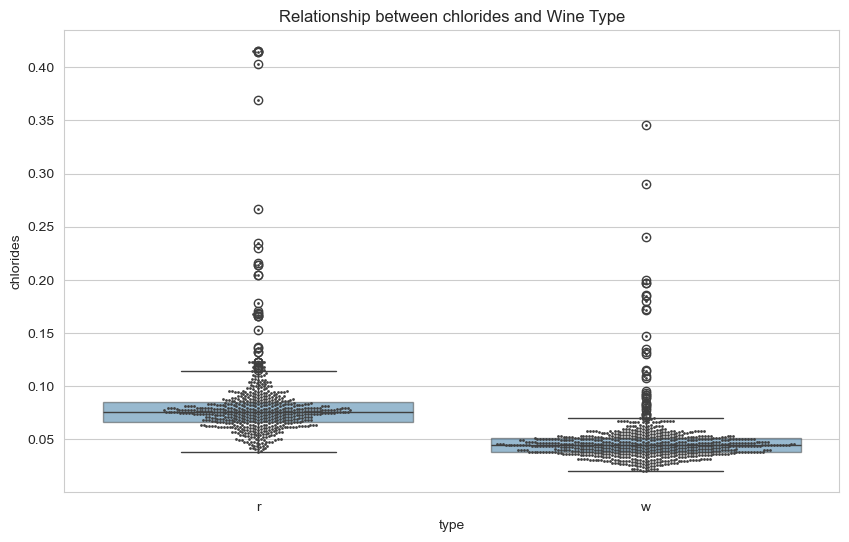

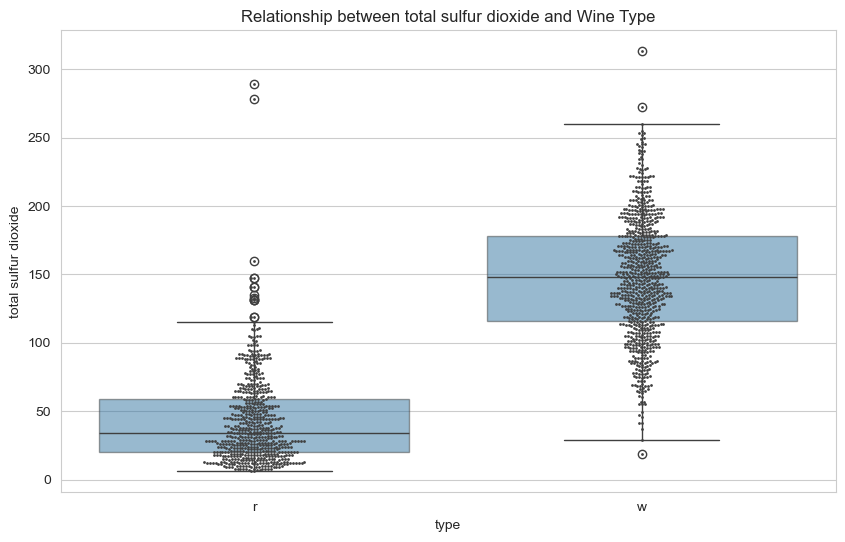

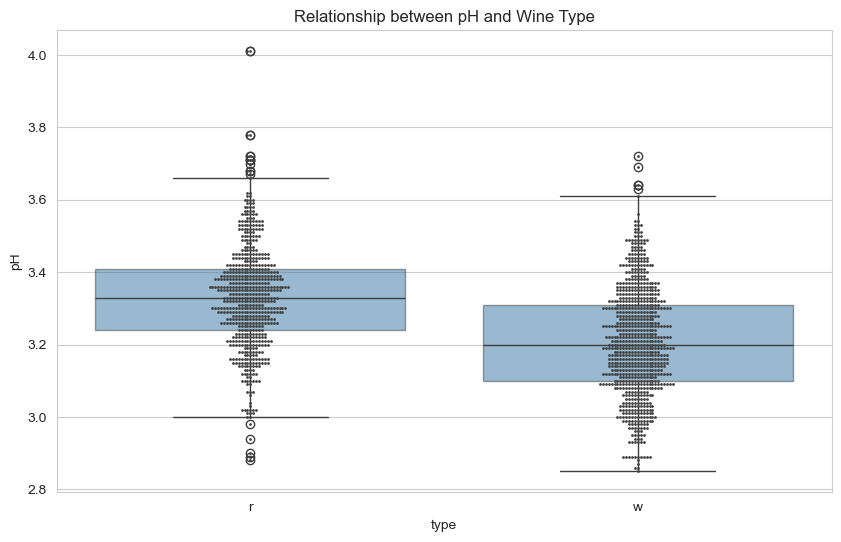

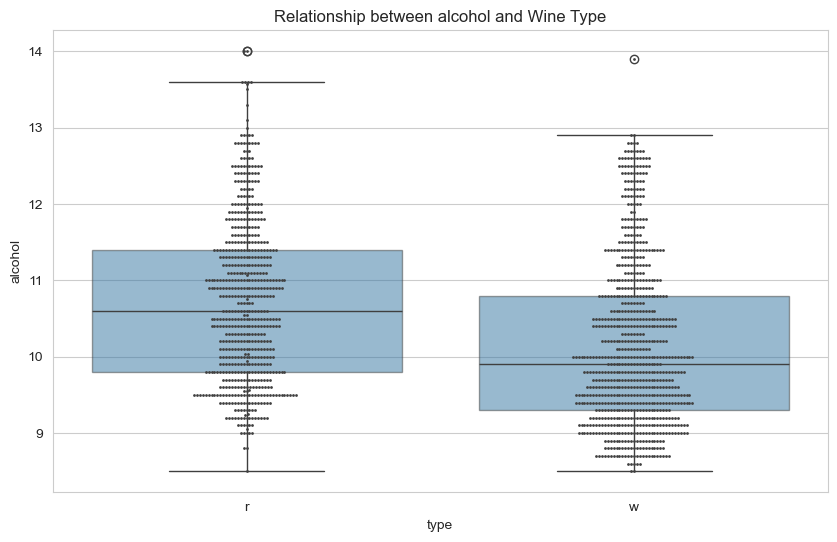

In [81]:
# 2. Identify numeric columns (assuming 5, e.g., 'fixed acidity', 'volatile acidity', etc.)
# and the target column (e.g., 'type' for red/white)
target_col = 'type' 
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns[:5]

# 3. Create plots for each numeric variable
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    
    # Mutual Boxplot
    sns.boxplot(x=target_col, y=col, data=df, boxprops=dict(alpha=0.5))
    
    # Mutual Swarmplot
    sns.swarmplot(x=target_col, y=col, data=df, color=".25", size=2)
    
    plt.title(f'Relationship between {col} and Wine Type')
    plt.show()

#### e)

Partition the dataset randomly into Train and Test datasets - 80% for Train and 20% for Test. On the Train set, fit a single multi-variate 5-level Decision Tree model for type of wines against all of the five other numeric variables. (6)

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

feature_cols = ['fixed acidity', 'total sulfur dioxide', 'pH', 'alcohol', 'chlorides'] 
target_col = 'type' # Replace with the actual target column name

X = df[feature_cols]
y = df[target_col]

# 3. Partition the dataset randomly into Train (80%) and Test (20%) datasets
# Using a fixed random_state ensures reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nData partitioned:")
print(f"  Training set size: {len(X_train)} samples")
print(f"  Test set size: {len(X_test)} samples")

# 4. Fit a single multi-variate 5-level Decision Tree model on the Train set
# We use the DecisionTreeClassifier from scikit-learn and set max_depth=5.
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the classifier on the training data
dt_classifier.fit(X_train, y_train)

print("\nDecision Tree model (max_depth=5) fitted successfully on the training data.")


Data partitioned:
  Training set size: 1116 samples
  Test set size: 280 samples

Decision Tree model (max_depth=5) fitted successfully on the training data.


#### f)

Predict type of wines using this model on both Train and Test datasets. Print the Classification Accuracy in both cases and plot the decision tree (specify `feature_name` and `class_names` correctly). (7)


Classification Accuracy on Training Data: 0.9910
Classification Accuracy on Test Data: 0.9821


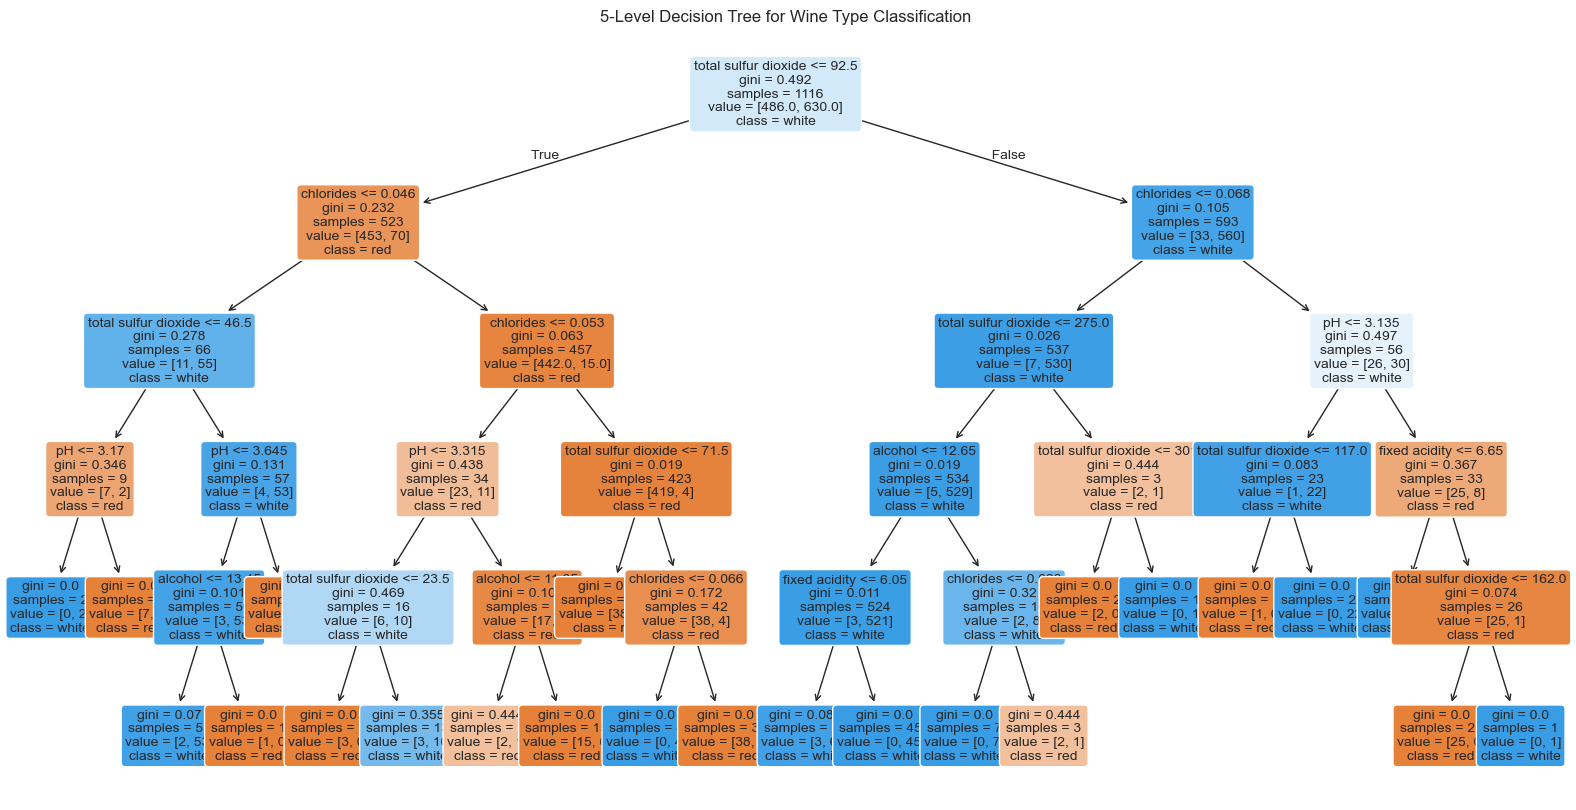

In [83]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Predict type of wines using this model on both Train and Test datasets
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

# Print the Classification Accuracy in both cases
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nClassification Accuracy on Training Data: {train_accuracy:.4f}")
print(f"Classification Accuracy on Test Data: {test_accuracy:.4f}")

# Plot the decision tree (specify feature_name and class_names correctly)
# Define class names based on your encoding (0 for red, 1 for white)
class_names = ['red', 'white']

plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, 
          feature_names=feature_cols, 
          class_names=class_names,
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("5-Level Decision Tree for Wine Type Classification")
plt.show()

#### g)

Compute from the Confusion Matrix, the values of false positive rate (`fpr`) and the false negative rate (`fnr`) and print these values. (2)


Confusion Matrix (Test Data):
[[127   2]
 [  3 148]]

False Positive Rate (FPR): 0.0155
False Negative Rate (FNR): 0.0199


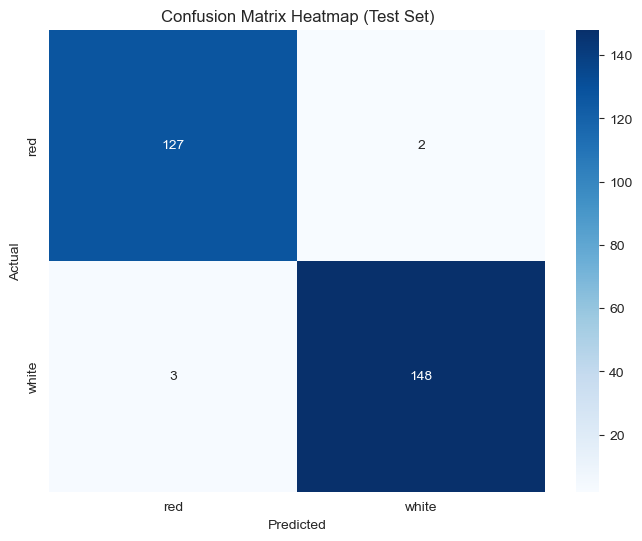

In [84]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Test Data):")
print(conf_matrix)

# Extract values from the confusion matrix
TN, FP, FN, TP = conf_matrix.ravel()

# Calculate rates
# FPR = FP / (FP + TN)
# FNR = FN / (FN + TP)

false_positive_rate = FP / (FP + TN) if (FP + TN) > 0 else 0
false_negative_rate = FN / (FN + TP) if (FN + TP) > 0 else 0

print(f"\nFalse Positive Rate (FPR): {false_positive_rate:.4f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap (Test Set)')
plt.show()

#### h)

Using a for loop, change the `max_depth` (up to 32) of your multivariate classifier. Plot in one figure with only one set of x- and y-, the classification accuracies of both the Training & Test sets (y-axis) against the depth of the tree (x-axis). Justify based on this plot, what is the best `max_depth` for this dataset and explain why. (6)

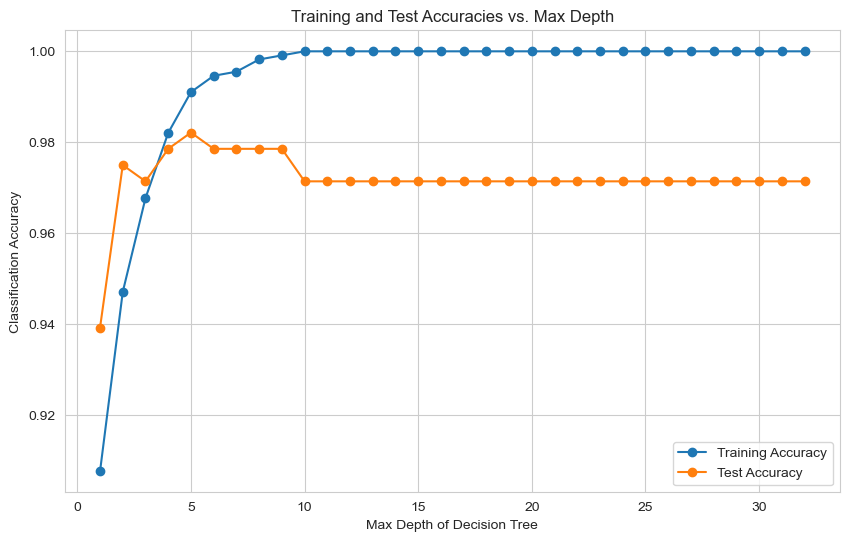


Optimal Max Depth based on Test Accuracy: 5
Justification: The plot shows that as the tree depth increases, the training accuracy continues to rise, but the test accuracy plateaus and might start to decline after a certain point (overfitting). The optimal depth is selected at the peak of the test accuracy to ensure good generalization to unseen data.


In [85]:
train_accuracies = []
test_accuracies = []
depths = range(1, 33) # Max depth up to 32

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    y_train_pred_loop = dt.predict(X_train)
    y_test_pred_loop = dt.predict(X_test)
    
    train_accuracies.append(accuracy_score(y_train, y_train_pred_loop))
    test_accuracies.append(accuracy_score(y_test, y_test_pred_loop))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(depths, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel('Max Depth of Decision Tree')
plt.ylabel('Classification Accuracy')
plt.title('Training and Test Accuracies vs. Max Depth')
plt.legend()
plt.grid(True)
plt.show()

# Justification of the best max_depth
# The best max_depth is typically where the test accuracy is highest and consistent.
# The graph will likely show training accuracy increasing and eventually reaching 1.0 (overfitting), 
# while test accuracy increases and then starts to decrease or level off. The optimal depth is the point 
# before the test accuracy starts to drop significantly.

optimal_depth = depths[np.argmax(test_accuracies)]
print(f"\nOptimal Max Depth based on Test Accuracy: {optimal_depth}")
print("Justification: The plot shows that as the tree depth increases, the training accuracy continues to rise, but the test accuracy plateaus and might start to decline after a certain point (overfitting). The optimal depth is selected at the peak of the test accuracy to ensure good generalization to unseen data.")

#### i)

Partition the dataset again into new Train and Test datasets - 70% for Train and 30% for Test and set `shuffle = False` within the arguments of the `train_test_split` function. On this Train set, fit a single multi-variate 3-level Decision Tree model for type of wines. Note: `shuffle = False` makes sure the split is not random. (5)

In [86]:
# Separate features (X) and target (y)
# Drop the target column from X
X = df.drop('type', axis=1) 
y = df['type']

# 2. Partition the dataset into Train and Test sets (70% train, 30% test, shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

print(f"\nTrain set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

# 3. Fit a single multivariate 3-level Decision Tree model on the Train set
# max_depth=3 ensures a 3-level (depth of 3) tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42) # random_state for reproducibility
dt_model.fit(X_train, y_train)

print("\nDecision Tree model fitted successfully to the training data.")


Train set size: 977 samples
Test set size: 419 samples

Decision Tree model fitted successfully to the training data.


#### j)

Write a block of code that takes all the rows from the dataframe for which the `fixed acidity` value is 8.5 and use your model in 2(e) predicts if the wine is red or white. Append the predicted column to the original dataframe. (4)

In [87]:
# Select rows where fixed acidity is 8.5
subset = df[df['fixed acidity'] == 8.5].copy()
X_subset = subset.drop('type', axis=1)

# Predict using the model from i)
predictions = dt_model.predict(X_subset)

# Append the predicted column to the subset
subset['predicted_type'] = predictions

print("\nRows with fixed acidity 8.5 and their predictions:")
print(subset[['fixed acidity', 'type', 'predicted_type']].head())


Rows with fixed acidity 8.5 and their predictions:
     fixed acidity type predicted_type
72             8.5    r              r
107            8.5    r              r
155            8.5    r              r
177            8.5    r              r
183            8.5    r              r


#### k)

Create a new dataframe with the entries below. Based on your model in 2(e), predict the type of wines for each of the combinations and use the print function to display type of wines (`red` or `white`). (5)

In [88]:
new_data = pd.DataFrame({
    'fixed acidity': [6.6, 5.9, 10.0, 5.8],
    'chlorides': [0.072, 0.049, 0.11, 0.047],
    'total sulfur dioxide':[56, 88, 36, 166],
    'pH':[3.35, 3.25, 3.12, 3.3],
    'alcohol':[9.2, 10.2, 10.8, 10.1]
})

new_predictions = dt_model.predict(new_data)
print("\nPredicted types for new data:")
print(new_predictions)


Predicted types for new data:
['r' 'r' 'r' 'w']


# Problem 3: Boring Data Regression (25)

#### a)

Import the provided dataset `boring.csv`, fit a univariate linear regression on this dataframe and show the value of the explained variance. (5)

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import explained_variance_score

df = pd.read_csv('boring.csv')

X = df[['index']]
y = df['boring']

model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)
ev_a = explained_variance_score(y, predictions)

print(f"a) Explained Variance (Original): {ev_a:.4f}")

a) Explained Variance (Original): 0.3621


#### b)

By plotting the index vs the boring numbers, what do you notice about the correlation? Based on this plot, rescale the column appropriately, save it as a new column and fit a new univariate linear regression that should produce a better model. Show the value of the explained variance and compare this number to the one extracted in (a) by discussing in a Markdown cell. Bonus: Do you recognize this number series? (20)

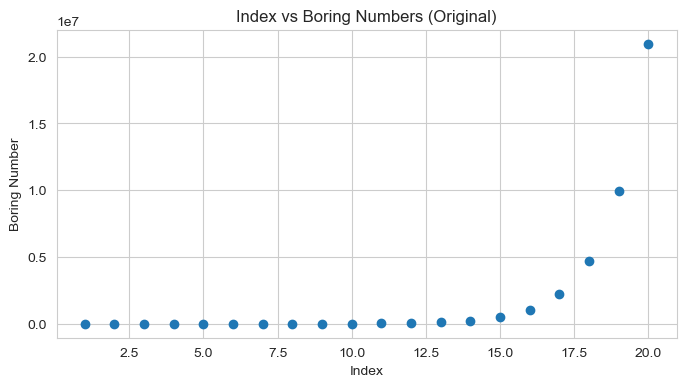

b) Explained Variance (Log Transformed): 0.9978
Comparison: The log-transformed model has a much higher R^2 (0.9978) compared to the original (0.3621), indicating a linear relationship exists in the log-space.


In [90]:
plt.figure(figsize=(8, 4))
plt.scatter(df['index'], df['boring'])
plt.title('Index vs Boring Numbers (Original)')
plt.xlabel('Index')
plt.ylabel('Boring Number')
plt.grid(True)
plt.show()

# Rescale: The plot shows exponential growth (specifically 2^n * poly(n)), 
# so a log transformation is appropriate to linearize the data.
df['log_boring'] = np.log(df['boring'])

# Fit new model
X_new = df[['index']]
y_new = df['log_boring']

model_new = LinearRegression()
model_new.fit(X_new, y_new)
predictions_new = model_new.predict(X_new)
ev_b = explained_variance_score(y_new, predictions_new)

print(f"b) Explained Variance (Log Transformed): {ev_b:.4f}")
print(f"Comparison: The log-transformed model has a much higher R^2 "
      f"({ev_b:.4f}) compared to the original ({ev_a:.4f}), "
      f"indicating a linear relationship exists in the log-space.")